In [ ]:
df = pd.read_csv('/content/train.csv', nrows=100000)  # remove nrows if you want full

print("Shape:", df.shape)
df.head()

Shape: (100000, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  100000 non-null  object 
 1   vendor_id           100000 non-null  int64  
 2   pickup_datetime     100000 non-null  object 
 3   dropoff_datetime    100000 non-null  object 
 4   passenger_count     100000 non-null  int64  
 5   pickup_longitude    100000 non-null  float64
 6   pickup_latitude     100000 non-null  float64
 7   dropoff_longitude   100000 non-null  float64
 8   dropoff_latitude    100000 non-null  float64
 9   store_and_fwd_flag  100000 non-null  object 
 10  trip_duration       100000 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 8.4+ MB


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.53349,1.667810,-73.973464,40.751059,-73.973455,40.751947,939.864260
std,0.49888,1.317603,0.038294,0.028152,0.036625,0.032452,3004.541199
min,1.00000,0.000000,-74.533875,40.433842,-74.562355,40.441662,1.000000
25%,1.00000,1.000000,-73.991852,40.737370,-73.991394,40.735844,396.000000
50%,2.00000,1.000000,-73.981712,40.754269,-73.979782,40.754478,662.000000
75%,2.00000,2.000000,-73.967209,40.768426,-73.962919,40.769928,1076.000000
max,2.00000,6.000000,-73.334023,41.319164,-72.711395,41.311520,86390.000000


In [ ]:
# Remove extreme outliers
df = df[df['trip_duration'] < 10000]

# Convert datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Extract features
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3


In [ ]:
df = df.drop(['id', 'pickup_datetime', 'dropoff_datetime'], axis=1, errors='ignore')
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day,month
0,2,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3
1,1,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6
2,2,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1
3,2,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4
4,2,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['store_and_fwd_flag'] = le.fit_transform(df['store_and_fwd_flag'])

In [ ]:
X = df.drop('trip_duration', axis=1)
y = df['trip_duration']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression
R2: 0.2093009322865097
MSE: 326140.19818760146


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print("R2:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))


Random Forest
R2: 0.7311117984505575
MSE: 110908.50479593492


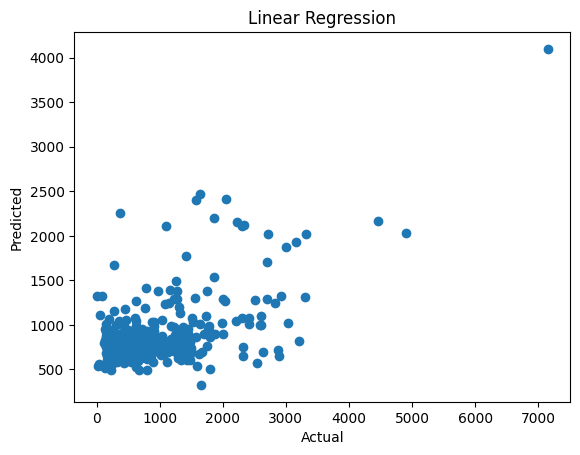

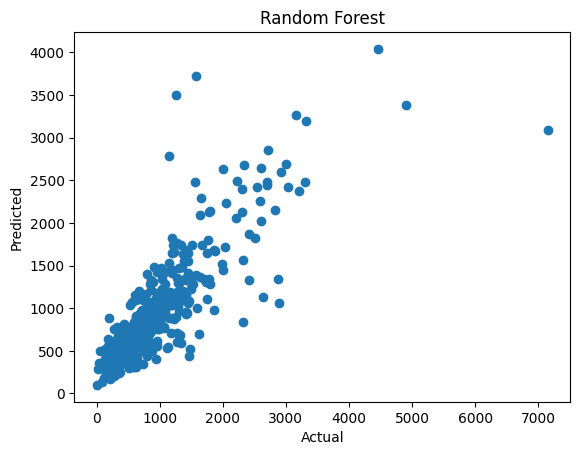

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test[:500], y_pred_lr[:500])
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

plt.figure()
plt.scatter(y_test[:500], y_pred_rf[:500])
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

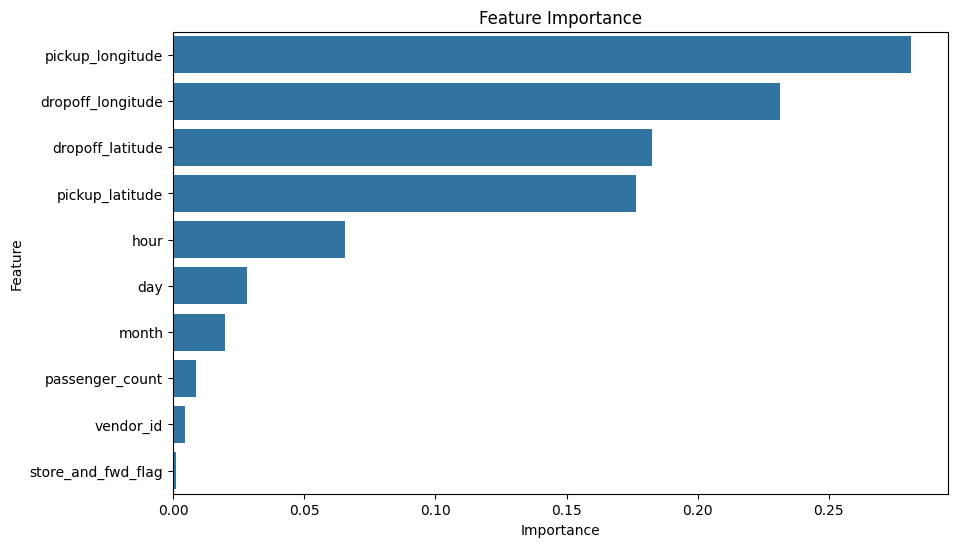

,Feature,Importance
2,pickup_longitude,0.281326
4,dropoff_longitude,0.231200
5,dropoff_latitude,0.182689
3,pickup_latitude,0.176345
7,hour,0.065710


In [ ]:
import pandas as pd
import seaborn as sns

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

feat_df.head()

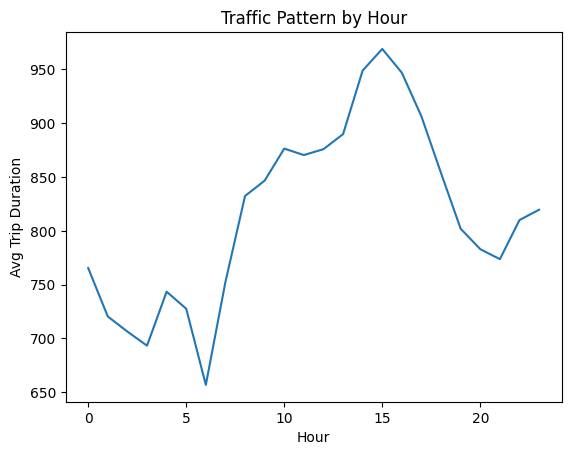

In [ ]:
hourly = df.groupby('hour')['trip_duration'].mean()

plt.figure()
hourly.plot()
plt.title("Traffic Pattern by Hour")
plt.xlabel("Hour")
plt.ylabel("Avg Trip Duration")
plt.show()

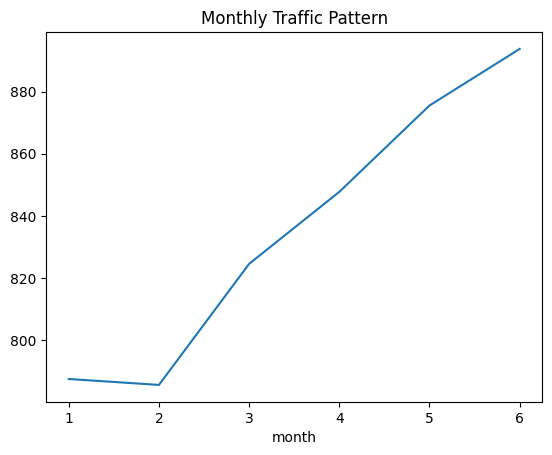

In [ ]:
monthly = df.groupby('month')['trip_duration'].mean()

plt.figure()
monthly.plot()
plt.title("Monthly Traffic Pattern")
plt.show()

In [ ]:
# ===============================
# MANUAL INPUT FROM USER
# ===============================

print("Enter values for prediction:")

vendor_id = int(input("vendor_id (1 or 2): "))
passenger_count = int(input("passenger_count: "))
pickup_longitude = float(input("pickup_longitude: "))
pickup_latitude = float(input("pickup_latitude: "))
dropoff_longitude = float(input("dropoff_longitude: "))
dropoff_latitude = float(input("dropoff_latitude: "))
store_and_fwd_flag = int(input("store_and_fwd_flag (0 or 1): "))
hour = int(input("hour (0-23): "))
day = int(input("day (1-31): "))
month = int(input("month (1-12): "))

# Combine into input
manual_input = [[
    vendor_id,
    passenger_count,
    pickup_longitude,
    pickup_latitude,
    dropoff_longitude,
    dropoff_latitude,
    store_and_fwd_flag,
    hour,
    day,
    month
]]

# Scale input
manual_scaled = scaler.transform(manual_input)

# Predict using Random Forest
prediction = rf.predict(manual_scaled)

print("\n🚖 Predicted Trip Duration (seconds):", prediction[0])

Enter values for prediction:
vendor_id (1 or 2): 2
passenger_count: 1
pickup_longitude: -73.98
pickup_latitude: 40.75
dropoff_longitude: -73.99
dropoff_latitude: 40.76
store_and_fwd_flag (0 or 1): 0
hour (0-23): 10
day (1-31): 15
month (1-12): 6

🚖 Predicted Trip Duration (seconds): 861.22


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
